In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.util import random_noise


In [15]:
# Load the image
image = cv2.imread('cham.jpg')

# convert to grayscale
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [16]:

image_gray=image_gray/255.0

In [17]:
#add different types of noise
gaussian_noise = random_noise(image_gray, mode='gaussian', var=0.01)
salt_pepper_noise = random_noise(image_gray, mode='s&p', amount=0.05)
poisson_noise = random_noise(image_gray, mode='poisson')
speckle_noise = random_noise(image_gray, mode='speckle', var=0.01)

In [18]:
#convert back to uint8 for display
def convert_to_uint8(image_gray):
    return (255 * np.clip(image_gray, 0, 1)).astype(np.uint8 )

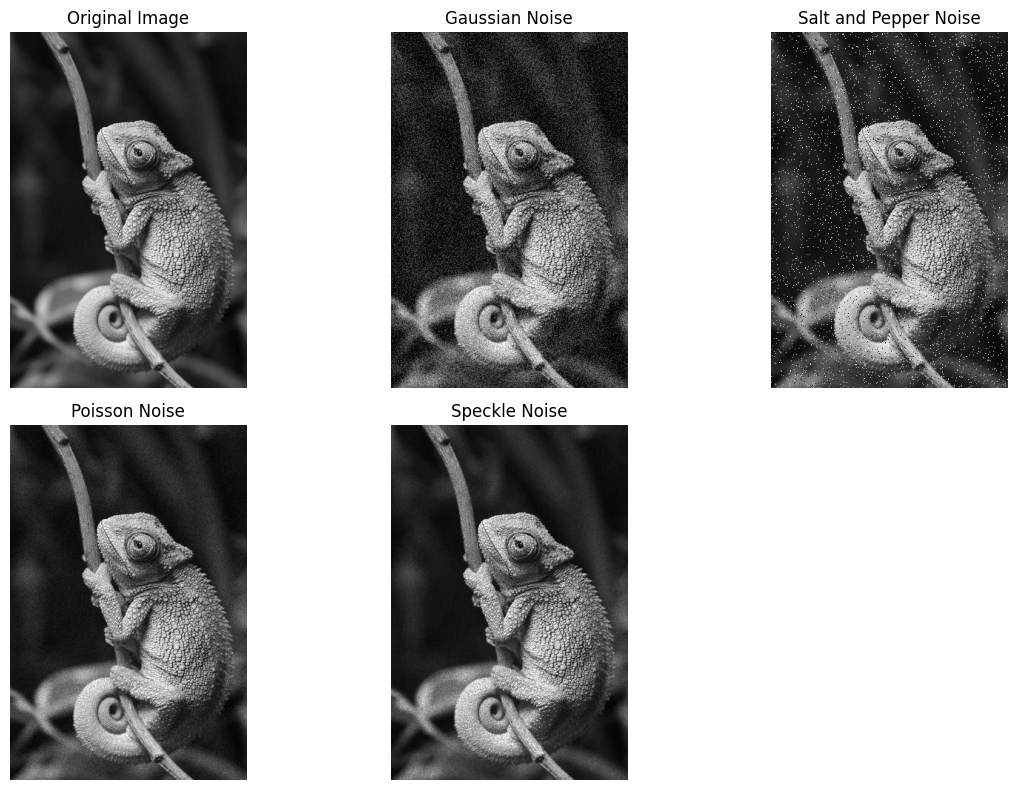

In [19]:
#display the images with oringinal and noisy images
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.imshow(convert_to_uint8(image_gray), cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(2, 3, 2)
plt.imshow(convert_to_uint8(gaussian_noise), cmap='gray')
plt.title('Gaussian Noise')
plt.axis('off')
plt.subplot(2, 3, 3)
plt.imshow(convert_to_uint8(salt_pepper_noise), cmap='gray')
plt.title('Salt and Pepper Noise')
plt.axis('off')
plt.subplot(2, 3, 4)
plt.imshow(convert_to_uint8(poisson_noise), cmap='gray')
plt.title('Poisson Noise')
plt.axis('off')
plt.subplot(2, 3, 5)
plt.imshow(convert_to_uint8(speckle_noise), cmap='gray')
plt.title('Speckle Noise')
plt.axis('off')
plt.tight_layout()
plt.show()

In [20]:
# image1 = cv2.imread('images.jpeg')
# image_gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)

In [21]:
# #add different types of noise
# gaussian_noise = random_noise(image_gray1, mode='gaussian', var=0.01)
# salt_pepper_noise = random_noise(image_gray1, mode='s&p', amount=0.05)
# poisson_noise = random_noise(image_gray1, mode='poisson')
# speckle_noise = random_noise(image_gray1, mode='speckle', var=0.01)

In [22]:
# #display the images without normalization
# plt.figure(figsize=(12, 8))
# plt.subplot(2, 3, 1)
# plt.imshow(image_gray1, cmap='gray')
# plt.title('Original Image')
# plt.axis('off')
# plt.subplot(2, 3, 2)
# plt.imshow(gaussian_noise, cmap='gray')
# plt.title('Gaussian Noise')
# plt.axis('off')
# plt.subplot(2, 3, 3)
# plt.imshow(salt_pepper_noise, cmap='gray')
# plt.title('Salt and Pepper Noise')
# plt.axis('off')
# plt.subplot(2, 3, 4)
# plt.imshow(poisson_noise, cmap='gray')
# plt.title('Poisson Noise')
# plt.axis('off')
# plt.subplot(2, 3, 5)
# plt.imshow(speckle_noise, cmap='gray')
# plt.title('Speckle Noise')
# plt.axis('off')
# plt.tight_layout()
# plt.show()


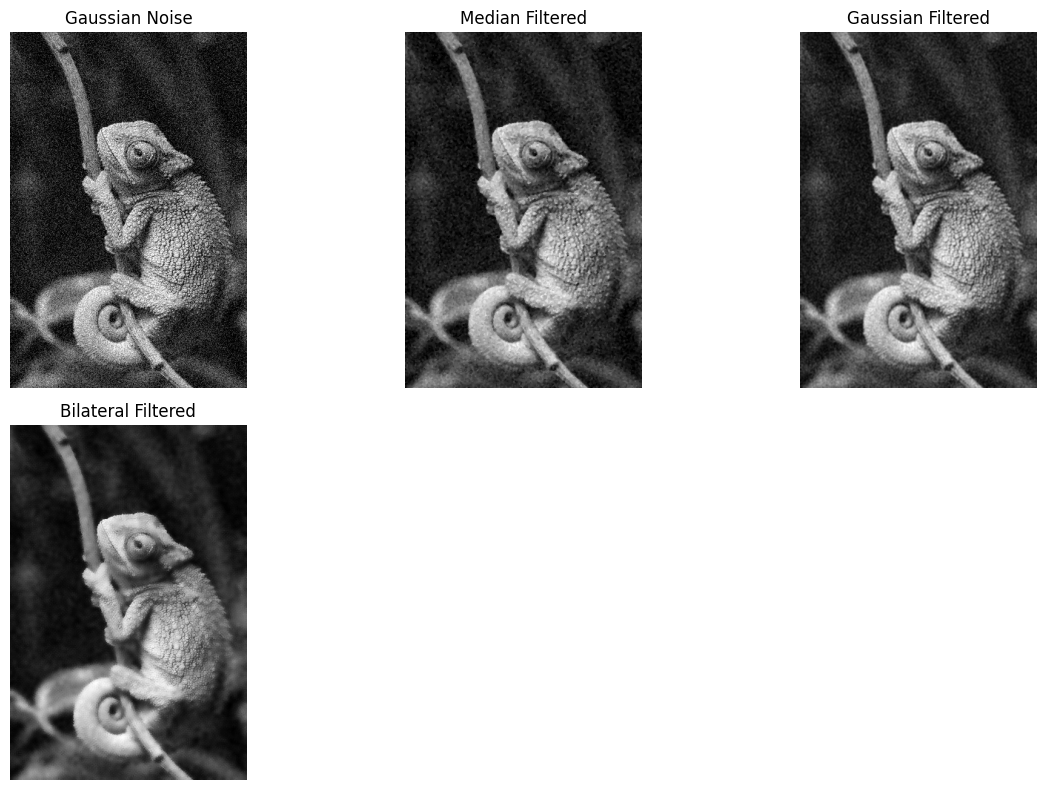

In [28]:
#remove the noise using median filter
def median_filter(gaussian_noise, kernel_size=3):
    return cv2.medianBlur(convert_to_uint8(gaussian_noise), kernel_size)
def gaussian_filter(gaussian_noise, kernel_size=3, sigma=1):
    return cv2.GaussianBlur(convert_to_uint8(gaussian_noise), (kernel_size, kernel_size), sigma)
def bilateral_filter(gaussian_noise, d=9, sigma_color=75, sigma_space=75):
    return cv2.bilateralFilter(convert_to_uint8(gaussian_noise), d, sigma_color, sigma_space)


# Apply filters
median_filtered = median_filter(gaussian_noise)
gaussian_filtered = gaussian_filter(gaussian_noise)
bilateral_filtered = bilateral_filter(gaussian_noise)  
# Display the filtered images
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.imshow(convert_to_uint8(gaussian_noise), cmap='gray')
plt.title('Gaussian Noise')
plt.axis('off')
plt.subplot(2, 3, 2)
plt.imshow(median_filtered, cmap='gray')
plt.title('Median Filtered')
plt.axis('off')
plt.subplot(2, 3, 3)
plt.imshow(gaussian_filtered, cmap='gray')
plt.title('Gaussian Filtered')
plt.axis('off')
plt.subplot(2, 3, 4)
plt.imshow(bilateral_filtered, cmap='gray')
plt.title('Bilateral Filtered')
plt.axis('off')
plt.tight_layout()
plt.show()



In [ ]:
#image 1 and 2
from skimage import metrics
image1=image_gray
image2=gaussian_noise
image3=gaussian_filtered


mse=metrics.mean_squared_error(image1, image2)
print(mse)

rmse=np.sqrt(mse)
print(rmse)


nrsme=metrics.normalized_root_mse(image1,image2)
print(nrsme)

psnr=metrics.peak_signal_noise_ratio(image1,image2)
print(psnr)


ssim=metrics.structural_similarity(image1,image2,data_range=image2.max() - image2.min())
print(ssim)

signal_power=np.mean(image1 ** 2)
noise_power=np.mean((image1 - image2) ** 2)
snr=10 * np.log10(signal_power / noise_power)
print(snr)


0.00877455743333606
0.09367260770009588
0.2660030740223429
20.567747790338867
0.3627911164713427
11.502266889692443


In [ ]:
#image 1 amd 3
from skimage import metrics



mse=metrics.mean_squared_error(image1, image3)
print(mse)

rmse=np.sqrt(mse)
print(rmse)


nrsme=metrics.normalized_root_mse(image1,image3)
print(nrsme)

psnr=metrics.peak_signal_noise_ratio(image1,image3)
print(psnr)


ssim=metrics.structural_similarity(image1,image3,data_range=image3.max() - image3.min())
print(ssim)

signal_power=np.mean(image1 ** 2)
noise_power=np.mean((image1 - image3) ** 2)
snr=10 * np.log10(signal_power / noise_power)
print(snr)


7800.169855928908
88.31857027788045
250.799158515905
-38.9210405995836
0.004550955155421935
-47.986521500230026


/var/folders/9k/f78pj45s44vcrflz9w3x210r0000gn/T/ipykernel_2570/1379875430.py:16: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  psnr=metrics.peak_signal_noise_ratio(image1,image3)


In [39]:
#image 2 and 3
from skimage import metrics



mse=metrics.mean_squared_error(image2, image3)
print(mse)

rmse=np.sqrt(mse)
print(rmse)


nrsme=metrics.normalized_root_mse(image2,image3)
print(nrsme)

psnr=metrics.peak_signal_noise_ratio(image2,image3)
print(psnr)


ssim=metrics.structural_similarity(image2,image3,data_range=image3.max() - image3.min())
print(ssim)

signal_power=np.mean(image2 ** 2)
noise_power=np.mean((image2 - image3) ** 2)
snr=10 * np.log10(signal_power / noise_power)
print(snr)


7799.038124075922
88.31216294529266
241.70505082978855
-38.920410433103044
0.004771457362922242
-47.665714516186696


/var/folders/9k/f78pj45s44vcrflz9w3x210r0000gn/T/ipykernel_2570/1615067082.py:16: UserWarning: Inputs have mismatched dtype.  Setting data_range based on image_true.
  psnr=metrics.peak_signal_noise_ratio(image2,image3)
